# AI Crypto Hedge Fund - Final Notebook

Execution mode: **FULL FINAL NOTEBOOK**.

This notebook is the single end-to-end reviewer narrative. It imports repository
package code and reads committed validation/final-test artifacts. It does not place
orders, download live data, call an external LLM or rerun/tune final-test strategies.


In [1]:
import os
import sys
from pathlib import Path


def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "src").exists():
            return candidate
    raise RuntimeError("Cannot locate repository root from notebook working directory.")


ROOT = find_repo_root(Path.cwd().resolve())
EXPECTED_VENV = (ROOT / ".venv").resolve()
RUNNING_PYTHON = Path(sys.executable).resolve()
RUNNING_PREFIX = Path(sys.prefix).resolve()
if RUNNING_PREFIX != EXPECTED_VENV:
    raise RuntimeError(
        "This notebook must run with the repository uv environment. "
        f"Run `uv sync --frozen`, then select {EXPECTED_VENV / 'bin/python'} "
        f"or run `make notebook-full`. Current interpreter: {RUNNING_PYTHON}; "
        f"current sys.prefix: {RUNNING_PREFIX}"
    )
os.chdir(ROOT)

import pandas as pd
from IPython.display import display

from crypto_hedge_fund.reporting import load_stage12_context
from crypto_hedge_fund.reporting.context import (
    representative_trace_rows,
)
from crypto_hedge_fund.reporting.notebook_display import (
    compact_frame,
    configure_notebook_display,
    format_cell,
    key_value_frame,
    plot_return_overview,
    plot_selected_nav,
    selected_summary_frame,
    short_hash,
)

configure_notebook_display()
ctx = load_stage12_context(ROOT)
print("final_test_lock_sha256:", ctx.lock_hash)
print("final_test_exposure:", ctx.suite_summary["final_test_exposure"])
print("final_test_dir:", ctx.final_dir.relative_to(ROOT).as_posix())
print("stage12_mode:", "FULL FINAL NOTEBOOK")

final_test_lock_sha256: c33b5eb396f60b1e2a7890616b8d9ae1cd69e91375dec925b68b6673d843af5e
final_test_exposure: EXPOSED
final_test_dir: artifacts/final_test/c33b5eb396f6
stage12_mode: FULL FINAL NOTEBOOK


## 1. Executive summary and coherent fund vision

The system is a reproducible historical research MVP for a risk-first AI-assisted
crypto portfolio. Agents produce scored proposals with confidence and cutoffs;
deterministic risk, allocation, rebalance and execution layers decide what can be
simulated. The MVP is long-only, unlevered, daily spot and educational.


In [2]:
display(selected_summary_frame(ctx))

,Level,Selected,Net return,Benchmark,Sharpe,Max DD,Costs
0,level_1,SMA baseline,-7.4%,-5.4%,-0.171,-18.5%,"$8,906"
1,level_2,agent_ensemble,-0.6%,-5.4%,-0.522,-1.4%,"$1,600"
2,level_3,cvar_downside,-18.0%,-25.4%,-0.023,-45.2%,"$1,493"
3,level_4,calendar_monthly,-4.1%,-9.3%,-0.880,-9.1%,"$3,584"
4,level_5,large_universe_dynamic,-28.0%,-45.2%,-0.218,-42.2%,"$110,939"


## 2. Reproducibility/environment/data hashes

The final-test lock and artifact metadata identify data, config, git, costs, period,
benchmark and seed values. The accepted lock is shown by package code above.


In [3]:
summary = ctx.suite_summary
display(
    key_value_frame(
        [
            ("Data SHA-256", short_hash(summary["data_sha256"])),
            ("Instruments SHA-256", short_hash(summary["instruments_sha256"])),
            ("Manifest SHA-256", short_hash(summary["manifest_sha256"])),
            ("Validation config SHA-256", short_hash(summary["validation_selected_sha256"])),
            (
                "Generated final config SHA-256",
                short_hash(summary["generated_final_config_sha256"]),
            ),
            ("Locked git commit", short_hash(summary["locked_git_commit"])),
            ("Runner git commit", short_hash(summary["git_commit"])),
            ("Period", summary["period"]),
            ("Costs", summary["cost_assumptions"]),
        ]
    )
)

,Metric,Value
0,Data SHA-256,9f539f38394240f5...b80d7e14
1,Instruments SHA-256,df7777139dd41060...7bddf18b
2,Manifest SHA-256,24b2263f9ffd125f...37fcbd3e
3,Validation config SHA-256,da1dcaf442517b6c...e72e77e8
4,Generated final config SHA-256,c6c79b974e7c46f4...b1522fc6
5,Locked git commit,d200df6d8a5bd167...9943a1e5
6,Runner git commit,d200df6d8a5bd167...9943a1e5
7,Period,"[2025-01-01, 2025-12-31]"
8,Costs,{'chargeable_notional': 'risky_asset_notional_...


## 3. Data preparation, provenance and quality

The included dataset is frozen daily spot OHLCV with instrument metadata and a manifest.
It is validated offline and carries the known active-market survivorship/delisting
limitation.


In [4]:
counts = ctx.level5_counts
health = ctx.health_summary.iloc[0]
display(
    key_value_frame(
        [
            ("Level 5 eligible pairs", counts["eligible_count"]),
            ("Level 5 scored pairs", counts["scored_count"]),
            ("Level 5 selected holdings", counts["selected_count"]),
            ("System status", health["system_status"]),
            ("Incident count", health["incident_count"]),
            ("Fail-safe scenarios", health["fail_safe_scenarios_demonstrated"]),
            ("Runtime", format_cell(counts["runtime_seconds"], "runtime_seconds")),
            ("Peak RSS", format_cell(counts["peak_rss_mb"], "peak_rss_mb")),
        ]
    )
)

,Metric,Value
0,Level 5 eligible pairs,120
1,Level 5 scored pairs,120
2,Level 5 selected holdings,25
3,System status,ok
4,Incident count,53
5,Fail-safe scenarios,"[""kill_switch_cash_schedule_unit_test"", ""volat..."
6,Runtime,78.4s
7,Peak RSS,848 MiB


## 4. Architecture and agent interaction trace

The shared flow is: frozen data -> causal features -> typed agents -> aggregator ->
pre-risk -> allocator -> rebalance controller -> post-risk -> orders/fills -> ledger
-> metrics/monitoring. The next cell prints a committed end-to-end Level 2 trace.


In [5]:
trace_rows = representative_trace_rows(ctx)
trace = pd.DataFrame(trace_rows)
display(
    compact_frame(
        trace,
        ["agent", "symbol", "score", "confidence", "fit_cutoff", "feature_cutoff", "reason_codes"],
        max_rows=10,
    )
)

,agent,symbol,score,confidence,fit_cutoff,feature_cutoff,reason_codes
0,sma_crossover,BTC/USDT,-1.000,0.228,2024-12-31T00:00:00+00:00,2025-01-01T00:00:00+00:00,ok
1,econometric_ar_garch,BTC/USDT,0.037,0.049,2024-12-31T00:00:00+00:00,2025-01-01T00:00:00+00:00,ok
2,ml_logistic,BTC/USDT,-0.128,0.128,2024-12-31T00:00:00+00:00,2025-01-01T00:00:00+00:00,ok
3,ml_hist_gradient_boosting,BTC/USDT,-0.236,0.236,2024-12-31T00:00:00+00:00,2025-01-01T00:00:00+00:00,ok
4,aggregator,BTC/USDT,-0.466,0.040,2024-12-31T00:00:00+00:00,2025-01-01T00:00:00+00:00,ok
5,post_risk,portfolio,approve,cash=100.0%,2025-01-01T00:00:00+00:00,2025-01-01T00:00:00+00:00,ok


## 5. Model validation and no-leakage protocol

Train data covers 2021-2023, validation covers 2024, and the frozen final test covers
2025. Stage 12 consumes the exposed final artifacts and does not retune choices.


## 6. Level 1 — Baseline Strategy for a Single Cryptocurrency.

BTC/USDT SMA baseline through the shared next-open engine.

In [6]:
frame = ctx.metrics["level_1"]
important = [
    "approach",
    "method",
    "policy",
    "selected_for_level_1",
    "net_total_return",
    "net_sharpe",
    "net_max_drawdown",
    "net_turnover",
    "net_total_cost",
    "net_benchmark_total_return",
    "eligible_count",
    "scored_count",
    "selected_count",
    "runtime_seconds",
    "peak_rss_mb",
]
display(compact_frame(frame, important, max_rows=8))

,Net return,Sharpe,Max DD,Turnover,Costs,Benchmark
0,-7.4%,-0.171,-18.5%,598.7%,"$8,906",-5.4%


## 7. Level 2 — Adding AI Agents, Econometrics and ML.

Single-pair technical, econometric, ML and ensemble agents.

In [7]:
frame = ctx.metrics["level_2"]
important = [
    "approach",
    "method",
    "policy",
    "selected_for_level_2",
    "net_total_return",
    "net_sharpe",
    "net_max_drawdown",
    "net_turnover",
    "net_total_cost",
    "net_benchmark_total_return",
    "eligible_count",
    "scored_count",
    "selected_count",
    "runtime_seconds",
    "peak_rss_mb",
]
display(compact_frame(frame, important, max_rows=8))

,Approach,selected_for_level_2,Net return,Sharpe,Max DD,Turnover,Costs,Benchmark
0,technical_sma,no,-7.9%,-0.383,-18.9%,915.6%,"$13,915",-5.4%
1,econometric_ar_garch,no,-3.7%,-1.411,-4.1%,2033.8%,"$29,711",-5.4%
2,ml_logistic,no,-0.4%,-0.602,-0.6%,193.6%,"$2,900",-5.4%
3,ml_hist_gradient_boosting,no,0.0%,0.020,-1.3%,462.3%,"$6,947",-5.4%
4,agent_ensemble,yes,-0.6%,-0.522,-1.4%,106.5%,"$1,600",-5.4%


## 8. Level 3 — Portfolio Management on Historical Data (5–7 assets, prior 12 months).

Static 5-7 asset portfolio estimated from the prior 12 months.

In [8]:
frame = ctx.metrics["level_3"]
important = [
    "approach",
    "method",
    "policy",
    "selected_for_level_3",
    "net_total_return",
    "net_sharpe",
    "net_max_drawdown",
    "net_turnover",
    "net_total_cost",
    "net_benchmark_total_return",
    "eligible_count",
    "scored_count",
    "selected_count",
    "runtime_seconds",
    "peak_rss_mb",
]
display(compact_frame(frame, important, max_rows=8))

,Method,selected_for_level_3,Net return,Sharpe,Max DD,Turnover,Costs,Benchmark
0,equal_weight,no,-25.4%,-0.125,-48.7%,99.5%,"$1,492",-25.4%
1,inverse_volatility,no,-16.4%,0.002,-44.8%,99.5%,"$1,493",-25.4%
2,minimum_variance,no,0.9%,0.280,-36.3%,99.5%,"$1,493",-25.4%
3,cvar_downside,yes,-18.0%,-0.023,-45.2%,99.5%,"$1,493",-25.4%


## 9. Level 4 — Dynamic Portfolio Rebalancing.

Dynamic small-portfolio rebalance policies selected on validation.

In [9]:
frame = ctx.metrics["level_4"]
important = [
    "approach",
    "method",
    "policy",
    "selected_for_level_4",
    "net_total_return",
    "net_sharpe",
    "net_max_drawdown",
    "net_turnover",
    "net_total_cost",
    "net_benchmark_total_return",
    "eligible_count",
    "scored_count",
    "selected_count",
    "runtime_seconds",
    "peak_rss_mb",
]
display(compact_frame(frame, important, max_rows=8))

,Policy,selected_for_level_4,Net return,Sharpe,Max DD,Turnover,Costs,Benchmark
0,static_level3_benchmark,no,-18.0%,-0.023,-45.2%,99.5%,"$1,493",-18.0%
1,calendar_monthly,yes,-4.1%,-0.880,-9.1%,237.3%,"$3,584",-9.3%
2,drift_monthly,no,3.8%,0.290,-23.5%,839.0%,"$12,733",-9.3%
3,signal_risk_monthly,no,3.8%,0.290,-23.5%,839.0%,"$12,733",-9.3%


## 10. Level 5 — Portfolio Expansion to 100+ Pairs.

Large-universe point-in-time scoring with dynamic top-K allocation.

In [10]:
frame = ctx.metrics["level_5"]
important = [
    "approach",
    "method",
    "policy",
    "selected_for_level_5",
    "net_total_return",
    "net_sharpe",
    "net_max_drawdown",
    "net_turnover",
    "net_total_cost",
    "net_benchmark_total_return",
    "eligible_count",
    "scored_count",
    "selected_count",
    "runtime_seconds",
    "peak_rss_mb",
]
display(compact_frame(frame, important, max_rows=8))

,Net return,Sharpe,Max DD,Turnover,Costs,Benchmark,Runtime,Peak RSS
0,-28.0%,-0.218,-42.2%,4924.5%,"$110,939",-45.2%,78.4s,848 MiB


## 11. Cross-level comparison, monitoring and fail-safes

Net after fees/slippage is primary. Monitoring includes data/model/system health,
agent disagreement, optimizer fallback, runtime, incidents and explicit fail-safe
scenarios.


,Level,Selected,Net return,Benchmark,Sharpe,Max DD,Costs
0,level_1,SMA baseline,-7.4%,-5.4%,-0.171,-18.5%,"$8,906"
1,level_2,agent_ensemble,-0.6%,-5.4%,-0.522,-1.4%,"$1,600"
2,level_3,cvar_downside,-18.0%,-25.4%,-0.023,-45.2%,"$1,493"
3,level_4,calendar_monthly,-4.1%,-9.3%,-0.880,-9.1%,"$3,584"
4,level_5,large_universe_dynamic,-28.0%,-45.2%,-0.218,-42.2%,"$110,939"


,Metric,Value
0,Level 5 eligible pairs,120
1,Level 5 scored pairs,120
2,Level 5 selected holdings,25
3,Approved nonzero max,25


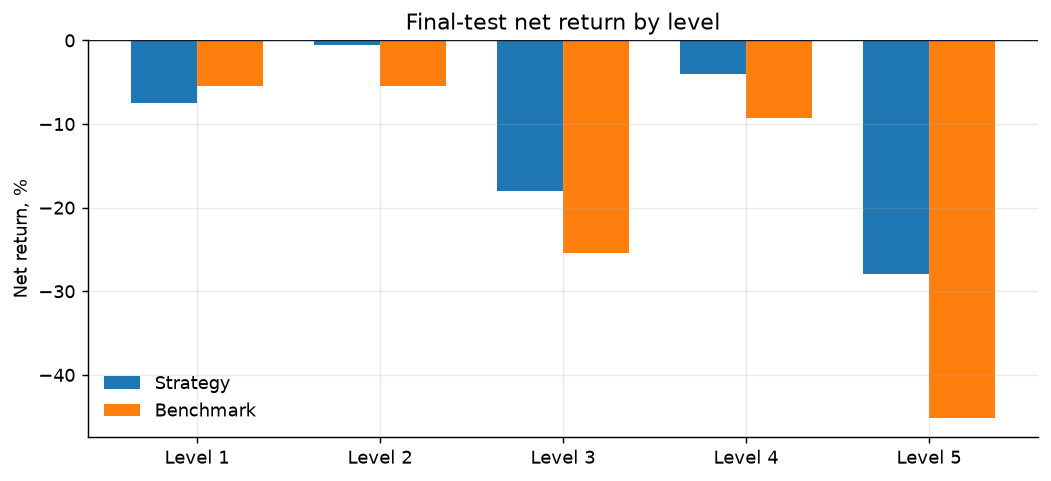

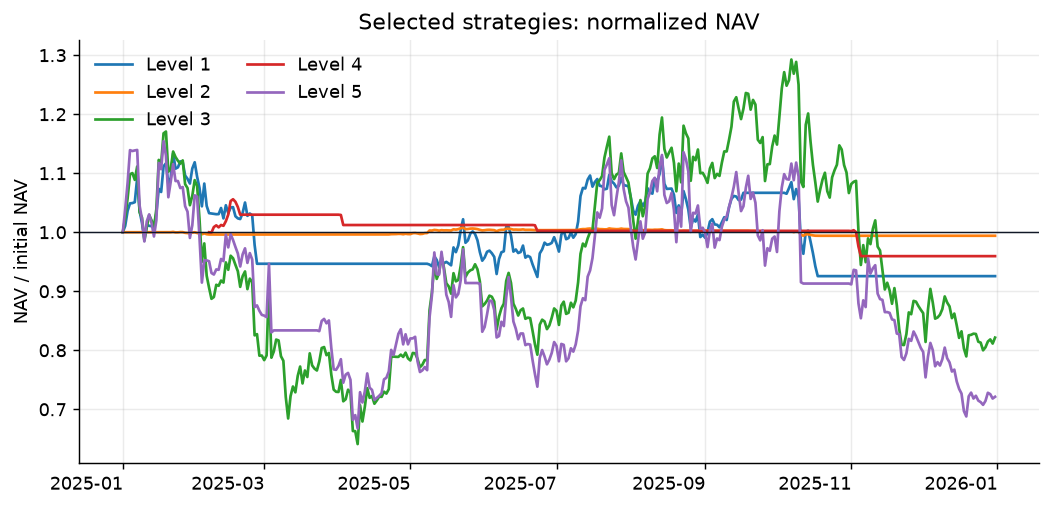

In [11]:
display(selected_summary_frame(ctx))
display(
    key_value_frame(
        [
            ("Level 5 eligible pairs", ctx.level5_pair_count_proof["eligible_count"]),
            ("Level 5 scored pairs", ctx.level5_pair_count_proof["scored_count"]),
            ("Level 5 selected holdings", ctx.level5_pair_count_proof["selected_count"]),
            ("Approved nonzero max", ctx.level5_pair_count_proof["approved_nonzero_count_max"]),
        ]
    )
)
plot_return_overview(ctx)
plot_selected_nav(ctx)

## 12. Limitations, real-trading application and production roadmap

Limitations: active-market survivorship/delisting bias, daily-bar liquidity proxies,
USDT cash assumption, simplified fills, cash-heavy risk behavior, and Level 5 top-K
benchmark rather than a full eligible-universe basket. Future work includes
multi-CEX adapters, order-book liquidity, reconciliation, Telegram controls and
news/sentiment ingestion. Those future items are not enabled in this MVP.
